# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

In [11]:
import pandas as pd

url = "https://drive.google.com/uc?id=1QwE8dqZw22s6KY52RhrpnQkiooEZUJ3d"
df = pd.read_csv(url)

print("Dataset Prediksi Cuaca")
df.head()

Dataset Prediksi Cuaca


,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


# Loading dataset

In [12]:
# Mengecek Struktur Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


# Cek Missing Value

In [17]:
df.isnull().sum()

,0
Temperature,0
Humidity,0
Wind Speed,0
Precipitation (%),0
Cloud Cover,0
Atmospheric Pressure,0
UV Index,0
Season,0
Visibility (km),0
Location,0


# Encode semua kolom kategori

In [15]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
label_encoders = {}

for col in df_encoded.columns:
    if df_encoded[col].dtype == "object":
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        label_encoders[col] = le


# Analisis korelasi antar fitur

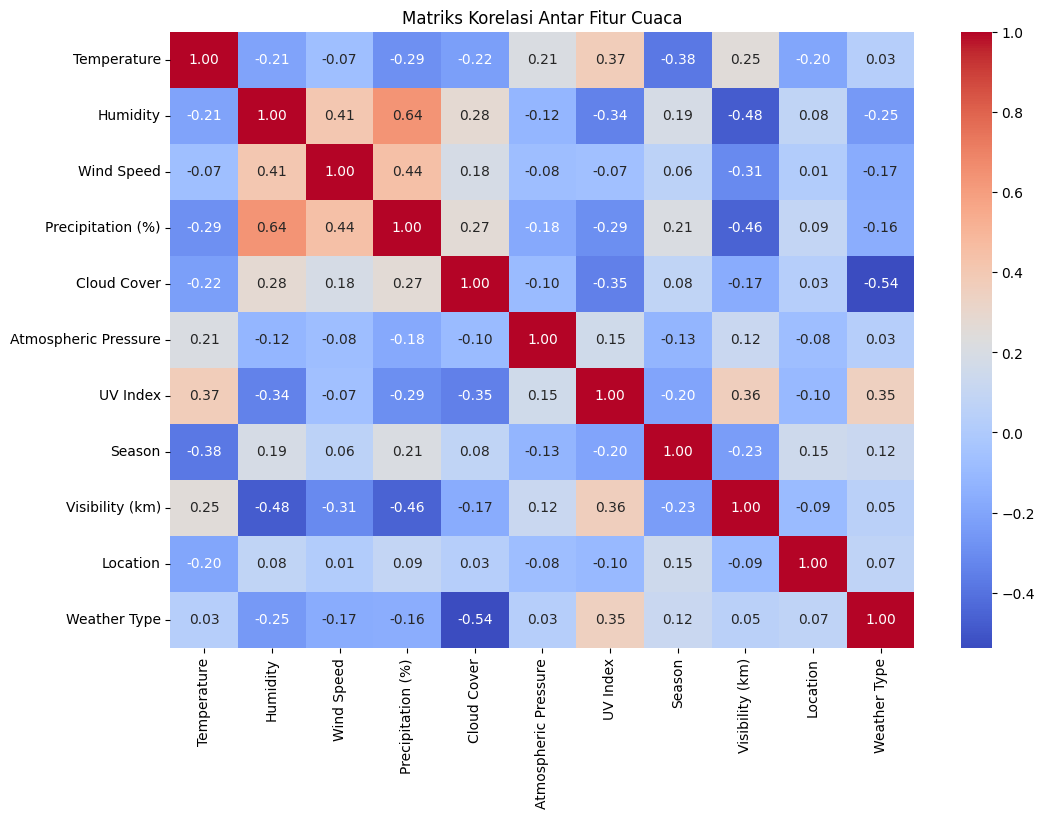

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung korelasi
corr = df_encoded.corr()

# Tampilkan matriks korelasi
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriks Korelasi Antar Fitur Cuaca")
plt.show()

# Visualisasi Distribusi Fitur

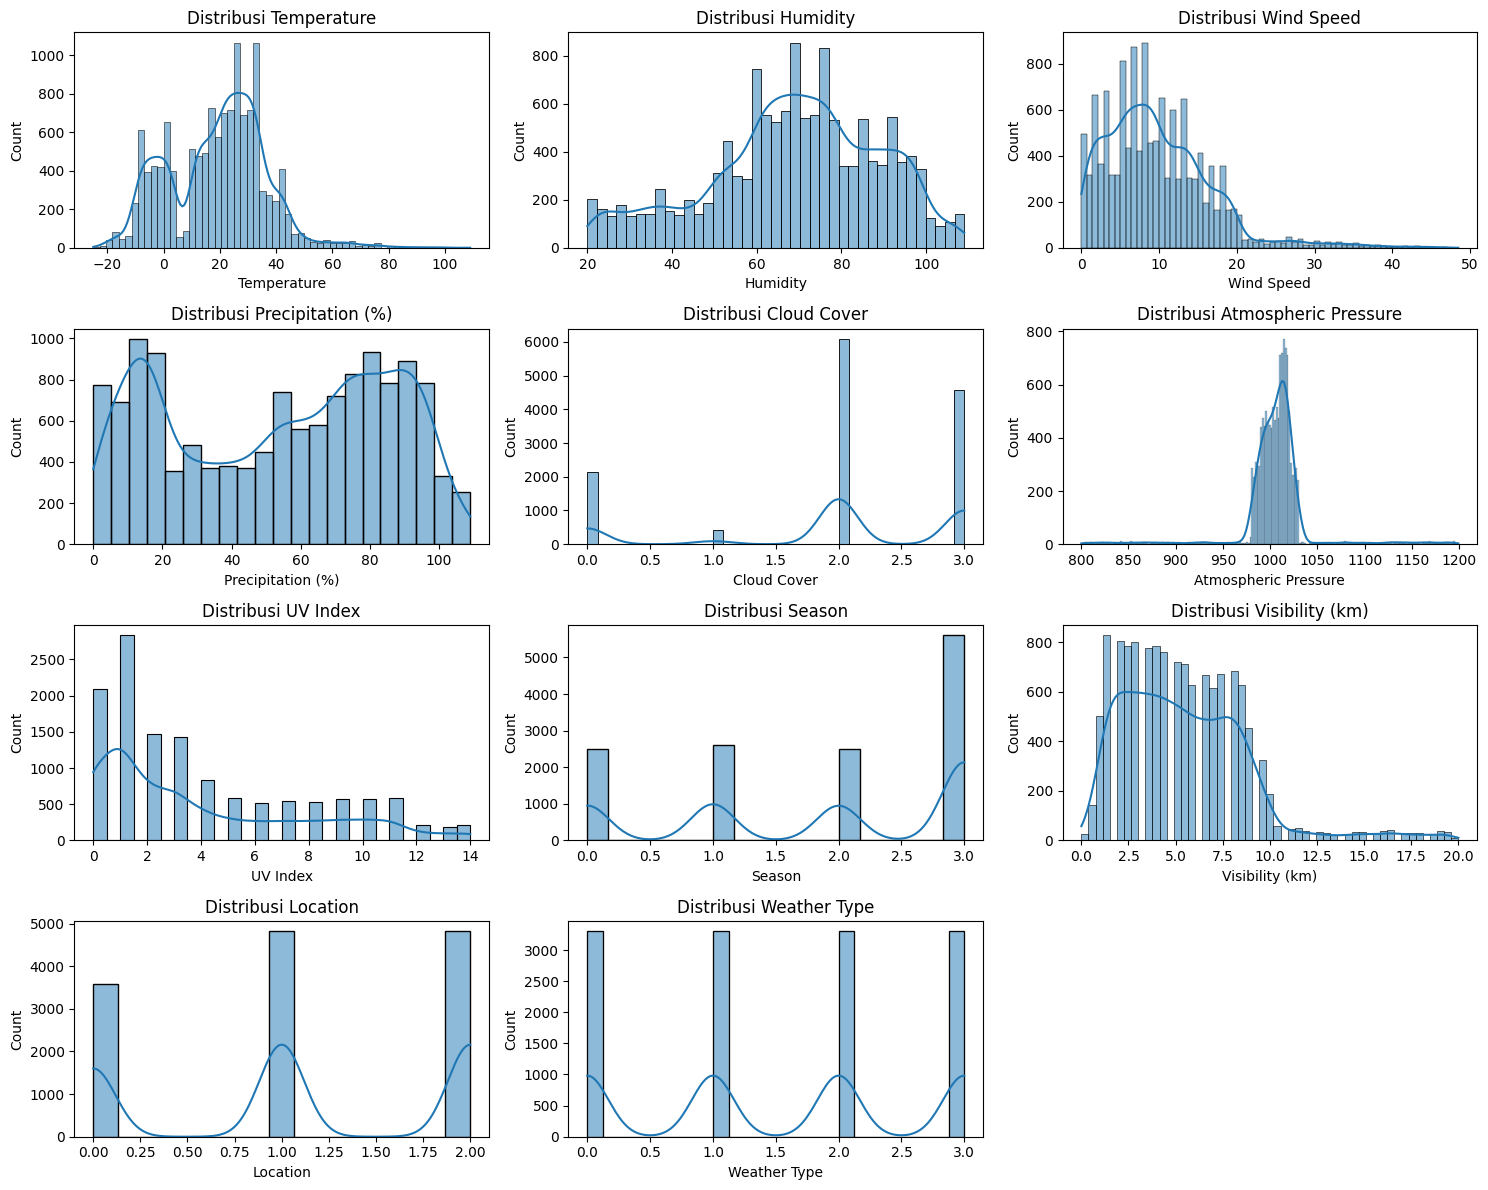

In [19]:
num_cols = df_encoded.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(15, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df_encoded[col], kde=True)
    plt.title(f"Distribusi {col}")

plt.tight_layout()
plt.show()

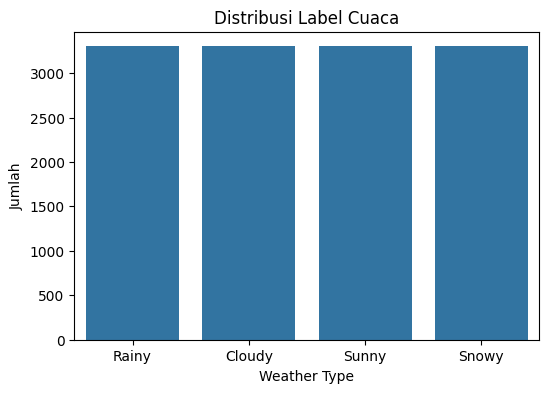

In [20]:
# Visualisasi Distribusi Label (Weather Type)

plt.figure(figsize=(6,4))
sns.countplot(x=df["Weather Type"])
plt.title("Distribusi Label Cuaca")
plt.xlabel("Weather Type")
plt.ylabel("Jumlah")
plt.show()

# Modelling

Pisahkan Fitur dan Label

In [21]:
X = df_encoded.drop("Weather Type", axis=1)
y = df_encoded["Weather Type"]

Train–Test Split

In [23]:
# 80% data untuk training, dan 20% untuk testing.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Normalisasi Fitur (Feature Scaling)

In [24]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
num_cols = df_encoded.select_dtypes(include=['int64','float64']).columns

df_scaled = df_encoded.copy()
df_scaled[num_cols] = scaler.fit_transform(df_scaled[num_cols])

In [25]:
df["Weather Type"].value_counts()

,count
Weather Type,
Rainy,3300
Cloudy,3300
Sunny,3300
Snowy,3300


SMOTE tidak diperlukan karena dataset sangat besar ada 13.200 baris dan sudah perfectly balanced, serta tidak ada kelas minoritas

# Hyperparameter Tuning (GridSearchCV)

In [26]:
param_grid = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()

grid = GridSearchCV(knn, param_grid, cv=5, scoring="accuracy")
grid.fit(X_train, y_train)

print("Best Parameters :", grid.best_params_)
print("Best Score      :", grid.best_score_)

Best Parameters : {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Best Score      : 0.8958333333333334


Training KNN dengan parameter terbaik

In [27]:
best_knn = grid.best_estimator_
best_knn.fit(X_train, y_train)

KNeighborsClassifier(metric='manhattan', weights='distance')

# Evaluasi Model KNN

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Prediksi
y_pred = best_knn.predict(X_test)

# Semua Eval
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8897727272727273

Confusion Matrix:

[[549  54  16  32]
 [ 34 576  15  22]
 [ 10  12 661  18]
 [ 24  34  20 563]]

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.84      0.87       651
           1       0.85      0.89      0.87       647
           2       0.93      0.94      0.94       701
           3       0.89      0.88      0.88       641

    accuracy                           0.89      2640
   macro avg       0.89      0.89      0.89      2640
weighted avg       0.89      0.89      0.89      2640



# Evaluasi dengan Confusion Matrix

In [29]:
from sklearn.metrics import confusion_matrix

# Evaluasi dengan Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("=== Confusion Matrix ===")
print(cm)

=== Confusion Matrix ===
[[549  54  16  32]
 [ 34 576  15  22]
 [ 10  12 661  18]
 [ 24  34  20 563]]


# Validasi Model dengan Cross Validation

In [30]:
cv_scores = cross_val_score(best_knn, X, y, cv=5, scoring="accuracy")

print("Cross Validation Scores:", cv_scores)
print("Rata-rata Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.88863636 0.89621212 0.89128788 0.8905303  0.88939394]
Rata-rata Accuracy: 0.8912121212121212


# Menentukan Nilai K Optimal (Elbow Method)

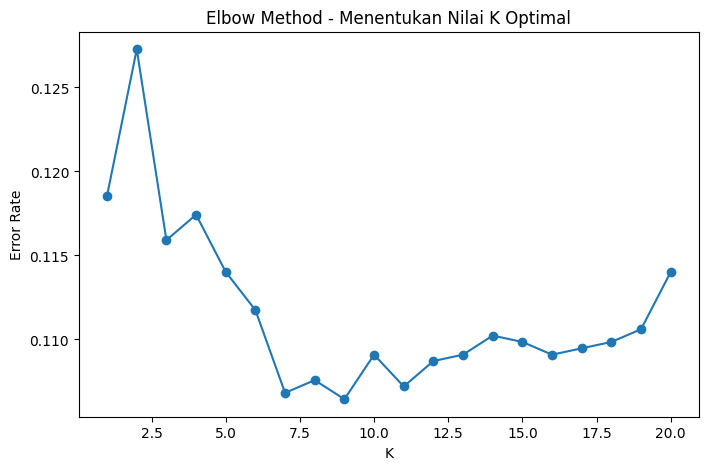

In [31]:
error_rates = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_test)
    error_rates.append(1 - accuracy_score(y_test, pred_k))

plt.figure(figsize=(8,5))
plt.plot(range(1,21), error_rates, marker="o")
plt.title("Elbow Method - Menentukan Nilai K Optimal")
plt.xlabel("K")
plt.ylabel("Error Rate")
plt.show()